# Importing Libraries

In [3]:
# torch and torchvision Libraries
import torch
from torch import nn 
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,WeightedRandomSampler
import torch.optim as Optim
import torch.optim.lr_scheduler as Scheduler
import torchvision


# Some More Data Science Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random
import os
from torchinfo import summary
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# pretrained models

from torchvision.models import resnet18


/run/media/chaman/secondary/project/myvenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Defining Directories

In [4]:
root = Path("Nifty_dataset")  # give path to folder containg train and test dataset images
train_dir = root / "train"
test_dir = root / "test"

print(f'Root Dir ---> {root}\nTrain Dir ---> {train_dir}\nTest Dir ---> {test_dir} ')

Root Dir ---> Nifty_dataset
Train Dir ---> Nifty_dataset/train
Test Dir ---> Nifty_dataset/test 


### Training Dataset Class Distribution

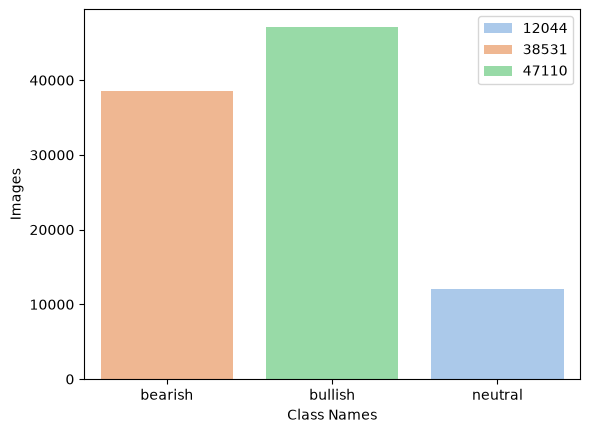

In [5]:

num_bearish = len(list(train_dir.glob("bearish/*.png")))
num_bullish = len(list(train_dir.glob("bullish/*.png")))
num_neutral = len(list(train_dir.glob("neutral/*.png")))

plt.xlabel("Class Names")
plt.ylabel("Images")
sns.color_palette("Spectral", as_cmap=True)
sns.barplot(y=[num_bearish,num_bullish,num_neutral],
            x=["bearish","bullish","neutral"],
            hue=[num_bearish,num_bullish,num_neutral],
            palette="pastel",
            orient="v");


### Applying Power-Scaled Inverse Frequency with WeightedRandomSampler

In [6]:


class_counts = (torch.tensor([num_bearish,num_bullish,num_neutral]))

inverse_counts = 1.0 / class_counts.float()

power_factor = 0.7 # high -> more balanced data [0-1]

class_weights_power = torch.pow(inverse_counts, power_factor)

class_weights_power = class_weights_power / class_weights_power.sum()


print(f'Trainig sample weights --> {class_weights_power} ')

train_dataset = ImageFolder(train_dir)

sample_weights = [class_weights_power[label].item() for label in train_dataset.targets]

sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)


Trainig sample weights --> tensor([0.2424, 0.2106, 0.5471]) 


# Displaying Random Training/Testing Images

In [7]:
def set_title_color(class_name : str) -> str :

    """
    Return : Given a class name -> bearish , bullish , neutral  return the respective color for title
    """
    if class_name == "bullish" :
        return "green"
    elif class_name == "bearish" :
        return "red"
    else :
        return "gray"

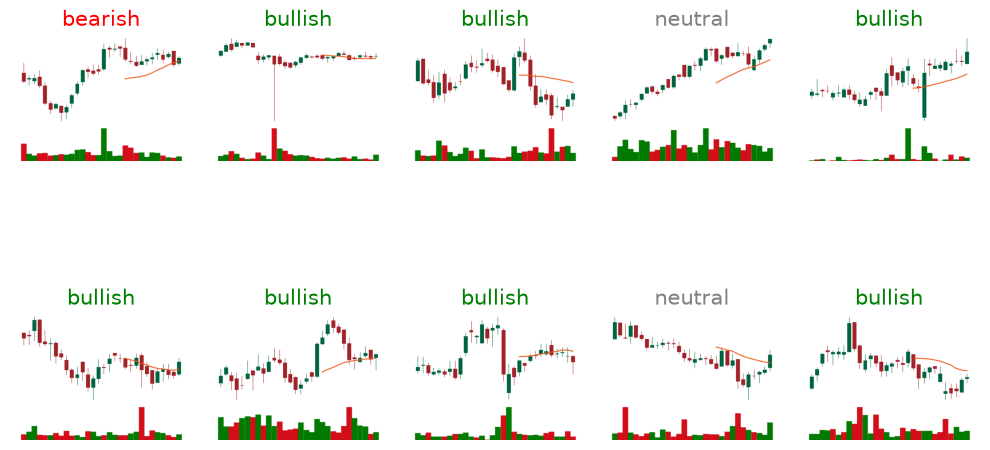

In [8]:
Seed = 42 # Set it to "None" if you want different images in very run

if Seed :
    random.seed(Seed)

path_list = list(train_dir.glob("*/*.png")) # you can replace "train_dir" with "test_dir"
random_images = random.sample(path_list,10)

plt.figure(figsize=(10,7))

for i in range(len(random_images)) :
    class_name = random_images[i].parent.name
    reading_image = plt.imread(random_images[i])


    plt.subplot(2,5,i+1)
    plt.title(class_name,color=set_title_color(class_name),fontsize=15)
    plt.axis(False)
    plt.imshow(reading_image)

plt.tight_layout()
plt.show()


In [9]:
def visualize_transformed_samples(
        dataset : torchvision.datasets.ImageFolder ,
        transforms = None,
) :
    """
    Visualise 10 random images from dataset after appling tranforming
    """

    random_images_idx = [i for i in random.sample(list(range(len(dataset))),k=10) ] 
    plt.figure(figsize=(10,7))
    for i in range(len(random_images_idx)) :
        random_image = dataset[random_images_idx[i]][0]

        class_name = dataset.classes[dataset[random_images_idx[i]][1]]
        
        random_image_trans = transforms(random_image) if transforms else random_image
        
        plt.subplot(2,5,i+1)
        plt.title(class_name,color=set_title_color(class_name),fontsize=15)
        plt.axis(False)
        plt.imshow(random_image_trans.permute(1,2,0).numpy())

    plt.tight_layout()
    plt.show()
        

# Tiny VGG

In [11]:
base_transforms = transforms.Compose(
    [
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ]
)



In [12]:
train_dataset = ImageFolder(train_dir,base_transforms,)

test_dataset = ImageFolder(test_dir,base_transforms)

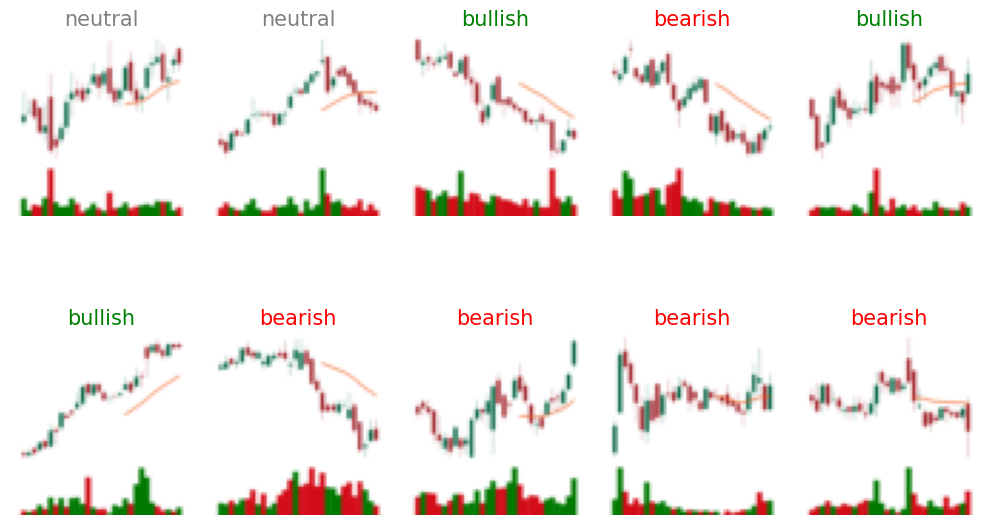

In [14]:
visualize_transformed_samples(train_dataset)

### Implemented TinyVGG architechture from ([CNN Explainer](https://poloclub.github.io/cnn-explainer/))

In [11]:
class TinyVGG(nn.Module) :
    def __init__(self,num_channel:int,hidden_units : int ,output_shape : int)  :
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=num_channel,out_channels=hidden_units,kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=1690,out_features=output_shape))

    def forward(self,x:torch.Tensor) -> torch.Tensor :
        
        return self.fc1(self.conv2(self.conv1(x)))
        

     

### Model Summary 

In [13]:
dummy_input = torch.randn(size=(32,3,64,64))
summary(TinyVGG(3,10,3),input_data=dummy_input)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

In [9]:
# Hyperparameters
EPOCHS = 10
BATCH_SIZE = 32

In [10]:
train_dataloader = DataLoader(train_dataset,
                              BATCH_SIZE,
                              sampler=sampler,
                              pin_memory=True)

test_dataloader = DataLoader(test_dataset,
                             BATCH_SIZE,
                             pin_memory=True)

NameError: name 'test_dataset' is not defined

In [337]:

model_1 = TinyVGG(num_channel=3,hidden_units=10,output_shape=3)

loss_fn = nn.CrossEntropyLoss()

optimiser = Optim.Adam(params=model_1.parameters() , lr=0.001)

scheduler = Scheduler.ConstantLR(optimiser,factor=0.1,total_iters=2)

# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu" 
 

### Training and Testing Loop for TinyVGG

In [ ]:
train_loss_arr = []
test_loss_arr = []
train_score_arr = []
test_score_arr = []

model_1 = model_1.to(device) # sending model to the device

for epoch in range(EPOCHS) :

    model_1.train()

    train_loss ,train_score , test_loss ,test_score = 0,0,0,0 # ecumulating average loss and score each epoch

    for batch_idx , (images , labels ) in enumerate(train_dataloader) :
        
        images , labels = images.to(device) , labels.to(device) # sendign inputs and labels to device


        y_train_logits = model_1(images) # getting raw logits

        y_train_prob = torch.softmax(y_train_logits,dim=1) # calculating probabilities for each class

        y_train_pred = torch.argmax(y_train_prob,dim=1) # geting final class for each input image

        loss = loss_fn(y_train_logits,labels.to(torch.long)) 
        train_loss += loss.item()

        score = accuracy_score(y_train_pred.to("cpu").numpy(),labels.to("cpu").numpy())
        train_score += score

        optimiser.zero_grad() # zeroing gradient for smooth calculations

        loss.backward()

        optimiser.step()

        current_images_processed = batch_idx * BATCH_SIZE

        if (current_images_processed % 9760 == 0) :

            print(f'Traing | Epoch {epoch} processed {current_images_processed}/{len(train_dataloader.dataset)}')

    train_loss /= len(train_dataloader)
    train_score /= len(train_dataloader)
    print("\n\n")

    model_1.eval()
    with torch.inference_mode() :

        for batch_idx ,(images,labels) in enumerate(test_dataloader) :

            images , labels = images.to(device) , labels.to(device)

            y_test_logits = model_1(images)
            y_test_prob = torch.softmax(y_test_logits,dim=1)
            y_test_pred = torch.argmax(y_test_prob,dim=1)

            loss = loss_fn(y_test_logits,labels.to(torch.long))
            test_loss+=loss.item()

            score = accuracy_score(y_test_pred.to("cpu").numpy(),labels.to("cpu").numpy())
            test_score += score

            current_images_processed = batch_idx * BATCH_SIZE

            if (current_images_processed % 2048 == 0) : 

                print(f'Testing | Epoch {epoch} processed {current_images_processed}/{len(test_dataloader.dataset)}')
        
        test_loss /= len(test_dataloader)
        test_score /= len(test_dataloader)
        
    scheduler.step()
       
    train_loss_arr.append(train_loss)
    test_loss_arr.append(test_loss)
    train_score_arr.append(train_score)
    test_score_arr.append(test_score)

    print(f'\nEPOCH {epoch} Summary\n')
    print(f'Train Loss {train_loss} | Train Acc {train_score}% | Test Loss {test_loss} | Test Acc {test_score}% ')



        





Traing | Epoch 0 processed 0/97685
Traing | Epoch 0 processed 9760/97685
Traing | Epoch 0 processed 19520/97685
Traing | Epoch 0 processed 29280/97685
Traing | Epoch 0 processed 39040/97685
Traing | Epoch 0 processed 48800/97685
Traing | Epoch 0 processed 58560/97685
Traing | Epoch 0 processed 68320/97685
Traing | Epoch 0 processed 78080/97685
Traing | Epoch 0 processed 87840/97685
Traing | Epoch 0 processed 97600/97685



Testing | Epoch 0 processed 0/22895
Testing | Epoch 0 processed 2048/22895
Testing | Epoch 0 processed 4096/22895
Testing | Epoch 0 processed 6144/22895
Testing | Epoch 0 processed 8192/22895
Testing | Epoch 0 processed 10240/22895
Testing | Epoch 0 processed 12288/22895
Testing | Epoch 0 processed 14336/22895
Testing | Epoch 0 processed 16384/22895
Testing | Epoch 0 processed 18432/22895
Testing | Epoch 0 processed 20480/22895
Testing | Epoch 0 processed 22528/22895

EPOCH 0 Summary

Train Loss 1.084973365117244 | Train Acc 0.37794060876889246% | Test Loss 1.0382276

###  Initialising directory for saving all models

In [9]:
models_path = Path("models")

### Saving  baseline model

In [17]:
torch.save(obj=model_1.state_dict(),f=models_path/"TinyVGG.pth")
print("Baseline models saved Successfully")

NameError: name 'model_1' is not defined

# VGG-19 Architecture: Custom PyTorch Implementation 
### Reference [GeeksforGeeks - VGG-Net Architecture Explained](https://www.geeksforgeeks.org/computer-vision/vgg-net-architecture-explained/)

#### Architectural ImprovementIn

This custom replication, the standard VGG-19 block has been enhanced by incorporating Batch Normalization to stabilize training and accelerate convergence across the deep network.

Block Sequence: Conv2d $\rightarrow$ BatchNorm2d $\rightarrow$ ReLU $\rightarrow$ MaxPool2d


In [9]:
class VGG19(nn.Module) :
    """ 
    Requires a image to be in RGB (3 channels) and expected size is 224 x 224 px
    
    Args :
        output : Number of Uniue classes in your dataset
    """

    def __init__(self,output : int) :
        super().__init__()

        self.block_1 = nn.Sequential(
            # Layer 1
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # Layer 2
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # pooling layer
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        # we will follow same architechture just some value will change

        self.block_2 = nn.Sequential(

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.block_3 = nn.Sequential(
            
            nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),

            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),

            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),

            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.block_4 = nn.Sequential(
            
            nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,stride=2,padding=1)
        )

        self.block_5 = nn.Sequential(
            
            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=512),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        
        # fully connected layers

        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=512*7*7,out_features=4096)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(in_features=4096,out_features=4096),
            nn.ReLU(),

            nn.Linear(in_features=4096,out_features=3)
        )



    def forward(self,x:torch.Tensor) -> torch.Tensor :
    
        return self.fc2(self.fc1(self.block_5(self.block_4(self.block_3(self.block_2(self.block_1(x)))))))



### VGG19 Model Summary

In [10]:
dummy_input = torch.randn(size=(32,3,224,224))
summary(model=VGG19(output=3),input_data=dummy_input)

Layer (type:depth-idx)                   Output Shape              Param #
VGG19                                    [32, 3]                   --
├─Sequential: 1-1                        [32, 64, 112, 112]        --
│    └─Conv2d: 2-1                       [32, 64, 224, 224]        1,792
│    └─BatchNorm2d: 2-2                  [32, 64, 224, 224]        128
│    └─ReLU: 2-3                         [32, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [32, 64, 224, 224]        36,928
│    └─BatchNorm2d: 2-5                  [32, 64, 224, 224]        128
│    └─ReLU: 2-6                         [32, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [32, 64, 112, 112]        --
├─Sequential: 1-2                        [32, 128, 56, 56]         --
│    └─Conv2d: 2-8                       [32, 128, 112, 112]       73,856
│    └─BatchNorm2d: 2-9                  [32, 128, 112, 112]       256
│    └─ReLU: 2-10                        [32, 128, 112, 112]       --
│

In [15]:
train_transforms = transforms.Compose(
    [
    
        transforms.Resize(size=(224,224)),
        transforms.RandomGrayscale(p= 0.5),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor()
    ]
)

test_transforms = transforms.Compose(
    [
    
        transforms.Resize(size=(224,224)),
        transforms.ToTensor()
    ]
)


In [16]:
train_dataset = ImageFolder(train_dir,transform=train_transforms)

test_dataset = ImageFolder(test_dir,transform=test_transforms)

In [17]:
EPOCHS = 15
BATCH_SIZE = 64

In [18]:
train_dataloader = train_dataloader = DataLoader(train_dataset,
                              BATCH_SIZE,
                              sampler=sampler,
                              pin_memory=True)

test_dataloader = DataLoader(test_dataset,
                             BATCH_SIZE,
                             pin_memory=True)

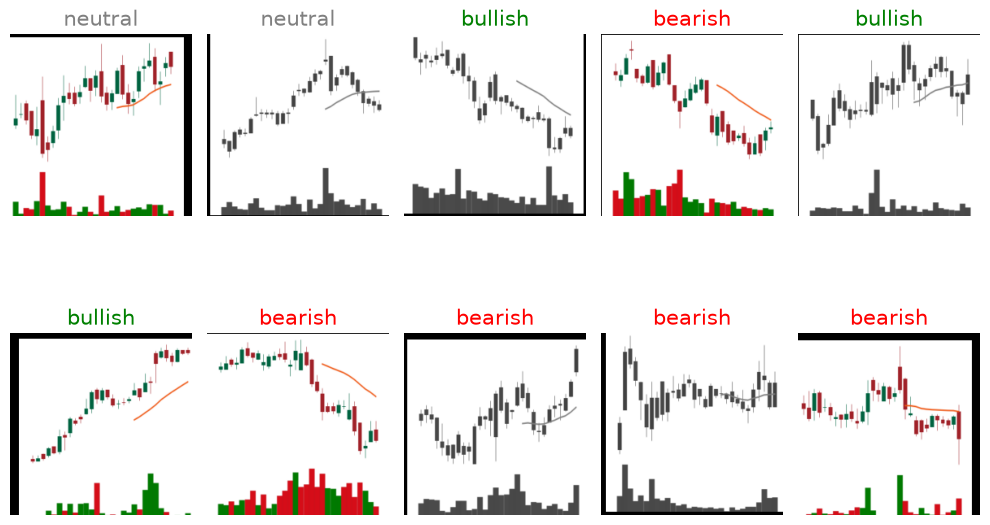

In [19]:
visualize_transformed_samples(dataset=train_dataset)

In [ ]:
# model_2 = VGG19(output=3)

# loss_fn = nn.CrossEntropyLoss()

# optimiser = Optim.Adam(params=model_2.parameters() , lr=0.01)

# scheduler = Scheduler.CosineAnnealingLR(optimizer=optimiser,
#                                         T_max=764*EPOCHS,
#                                         eta_min=1e-6)

# # Device agnostic code
# device = "cuda" if torch.cuda.is_available() else "cpu" 
 

In [ ]:
# model_2 = VGG19(output=3)

# loss_fn = nn.CrossEntropyLoss()

# optimiser = Optim.Adam(params=model_2.parameters() , lr=0.01)

# scheduler = Scheduler.CosineAnnealingLR(optimizer=optimiser,
#                                         T_max=764*EPOCHS,
#                                         eta_min=1e-6)

# # Device agnostic code
# device = "cuda" if torch.cuda.is_available() else "cpu" 
 

### Traing and Testing VGG19

In [54]:
# train_loss_arr = []
# test_loss_arr = []
# train_score_arr = []
# test_score_arr = []

# model_2 = model_2.to(device) # sending model to the device

# for epoch in range(EPOCHS) :

#     model_2.train()

#     train_loss ,train_score , test_loss ,test_score = 0,0,0,0 # ecumulating average loss and score each epoch

#     for batch_idx , (images , labels ) in enumerate(train_dataloader) :
        
#         images , labels = images.to(device) , labels.to(device) # sendign inputs and labels to device


#         y_train_logits = model_2(images) # getting raw logits

#         y_train_prob = torch.softmax(y_train_logits,dim=1) # calculating probabilities for each class

#         y_train_pred = torch.argmax(y_train_prob,dim=1) # geting final class for each input image

#         loss = loss_fn(y_train_logits,labels.to(torch.long)) 
#         train_loss += loss.item()

#         score = accuracy_score(y_train_pred.to("cpu").numpy(),labels.to("cpu").numpy())
#         train_score += score

#         optimiser.zero_grad() # zeroing gradient for smooth calculations

#         loss.backward()

#         optimiser.step()

#         current_images_processed = batch_idx * BATCH_SIZE

#         if (current_images_processed % 9760 == 0) :

#             print(f'Traing | Epoch {epoch} processed {current_images_processed}/{len(train_dataloader.dataset)}')

#     train_loss /= len(train_dataloader)
#     train_score /= len(train_dataloader)
#     print("\n\n")

#     model_1.eval()
#     with torch.inference_mode() :

#         for batch_idx ,(images,labels) in enumerate(test_dataloader) :

#             images , labels = images.to(device) , labels.to(device)

#             y_test_logits = model_2(images)
#             y_test_prob = torch.softmax(y_test_logits,dim=1)
#             y_test_pred = torch.argmax(y_test_prob,dim=1)

#             loss = loss_fn(y_test_logits,labels.to(torch.long))
#             test_loss+=loss.item()

#             score = accuracy_score(y_test_pred.to("cpu").numpy(),labels.to("cpu").numpy())
#             test_score += score

#             current_images_processed = batch_idx * BATCH_SIZE

#             if (current_images_processed % 2048 == 0) : 

#                 print(f'Testing | Epoch {epoch} processed {current_images_processed}/{len(test_dataloader.dataset)}')
        
#         test_loss /= len(test_dataloader)
#         test_score /= len(test_dataloader)
        
#     scheduler.step()
       
#     train_loss_arr.append(train_loss)
#     test_loss_arr.append(test_loss)
#     train_score_arr.append(train_score)
#     test_score_arr.append(test_score)

#     print(f'\nEPOCH {epoch} Summary\n')
#     print(f'Train Loss {train_loss} | Train Acc {train_score}% | Test Loss {test_loss} | Test Acc {test_score}% ')



        





In [20]:
model_3 = resnet18(weights=None,progress=True)
model_3.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512,out_features=3,bias=True)
        )

loss_fn = nn.CrossEntropyLoss()

optimiser = Optim.Adam(params=model_3.parameters() , lr=1e-4,weight_decay=1e-5)

scheduler = Scheduler.CosineAnnealingLR(optimizer=optimiser,
                                        T_max=EPOCHS,
                                        eta_min=1e-8)

# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu" 


In [19]:
summary(model_3,input_data=torch.randn(size=(64,3,224,224)))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [64, 3]                   --
├─Conv2d: 1-1                            [64, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [64, 64, 112, 112]        128
├─ReLU: 1-3                              [64, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [64, 64, 56, 56]          --
├─Sequential: 1-5                        [64, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [64, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [64, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [64, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [64, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [64, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [64, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [64, 64, 56, 56]          --
│

In [36]:
train_loss_arr = []
test_loss_arr = []
train_score_arr = []
test_score_arr = []

model_3 = model_3.to(device) # sending model to the device

for epoch in tqdm(range(EPOCHS)) :

    model_3.train()

    train_loss ,train_score , test_loss ,test_score = 0,0,0,0 # ecumulating average loss and score each epoch

    for batch_idx , (images , labels ) in enumerate(train_dataloader) :
        
        images , labels = images.to(device) , labels.to(device) # sendign inputs and labels to device


        y_train_logits = model_3(images) # getting raw logits

        y_train_prob = torch.softmax(y_train_logits,dim=1) # calculating probabilities for each class

        y_train_pred = torch.argmax(y_train_prob,dim=1) # geting final class for each input image

        loss = loss_fn(y_train_logits,labels.to(torch.long)) 
        train_loss += loss.item()

        score = accuracy_score(y_train_pred.to("cpu").numpy(),labels.to("cpu").numpy())
        train_score += score

        optimiser.zero_grad() # zeroing gradient for smooth calculations

        loss.backward()

        optimiser.step()

        current_images_processed = batch_idx * BATCH_SIZE

        if (current_images_processed % 9760 == 0) :

            print(f'Traing | Epoch {epoch} processed {current_images_processed}/{len(train_dataloader.dataset)}')

    train_loss /= len(train_dataloader)
    train_score /= len(train_dataloader)
    print("\n\n")

    model_3.eval()
    with torch.inference_mode() :

        for batch_idx ,(images,labels) in enumerate(test_dataloader) :

            images , labels = images.to(device) , labels.to(device)

            y_test_logits = model_3(images)
            y_test_prob = torch.softmax(y_test_logits,dim=1)
            y_test_pred = torch.argmax(y_test_prob,dim=1)

            loss = loss_fn(y_test_logits,labels.to(torch.long))
            test_loss+=loss.item()

            score = accuracy_score(y_test_pred.to("cpu").numpy(),labels.to("cpu").numpy())
            test_score += score

            current_images_processed = batch_idx * BATCH_SIZE

            if (current_images_processed % 2048 == 0) : 

                print(f'Testing | Epoch {epoch} processed {current_images_processed}/{len(test_dataloader.dataset)}')
        
        test_loss /= len(test_dataloader)
        test_score /= len(test_dataloader)
        
    scheduler.step()
       
    train_loss_arr.append(train_loss)
    test_loss_arr.append(test_loss)
    train_score_arr.append(train_score)
    test_score_arr.append(test_score)

    print(f'\nEPOCH {epoch} Summary\n')
    print(f'Train Loss {train_loss:.4f} | Train Acc {train_score*100:.4f}% | Test Loss {test_loss:.4f} | Test Acc {test_score*100:.4f}% ')



        





  0%|          | 0/15 [00:00<?, ?it/s]

Traing | Epoch 0 processed 0/97685
Traing | Epoch 0 processed 19520/97685
Traing | Epoch 0 processed 39040/97685
Traing | Epoch 0 processed 58560/97685
Traing | Epoch 0 processed 78080/97685
Traing | Epoch 0 processed 97600/97685



Testing | Epoch 0 processed 0/22895
Testing | Epoch 0 processed 2048/22895
Testing | Epoch 0 processed 4096/22895
Testing | Epoch 0 processed 6144/22895
Testing | Epoch 0 processed 8192/22895
Testing | Epoch 0 processed 10240/22895
Testing | Epoch 0 processed 12288/22895
Testing | Epoch 0 processed 14336/22895
Testing | Epoch 0 processed 16384/22895
Testing | Epoch 0 processed 18432/22895
Testing | Epoch 0 processed 20480/22895
Testing | Epoch 0 processed 22528/22895


  7%|▋         | 1/15 [07:41<1:47:36, 461.16s/it]


EPOCH 0 Summary

Train Loss 1.1186 | Train Acc 36.7657% | Test Loss 1.0437 | Test Acc 42.3184% 
Traing | Epoch 1 processed 0/97685
Traing | Epoch 1 processed 19520/97685
Traing | Epoch 1 processed 39040/97685
Traing | Epoch 1 processed 58560/97685
Traing | Epoch 1 processed 78080/97685
Traing | Epoch 1 processed 97600/97685



Testing | Epoch 1 processed 0/22895
Testing | Epoch 1 processed 2048/22895
Testing | Epoch 1 processed 4096/22895
Testing | Epoch 1 processed 6144/22895
Testing | Epoch 1 processed 8192/22895
Testing | Epoch 1 processed 10240/22895
Testing | Epoch 1 processed 12288/22895
Testing | Epoch 1 processed 14336/22895
Testing | Epoch 1 processed 16384/22895
Testing | Epoch 1 processed 18432/22895
Testing | Epoch 1 processed 20480/22895
Testing | Epoch 1 processed 22528/22895


 13%|█▎        | 2/15 [15:27<1:40:31, 464.00s/it]

...


EPOCH 12 Summary

Train Loss 1.0545 | Train Acc 44.1455% | Test Loss 1.0570 | Test Acc 43.4075% 
Traing | Epoch 13 processed 0/97685
Traing | Epoch 13 processed 19520/97685
Traing | Epoch 13 processed 39040/97685
Traing | Epoch 13 processed 58560/97685
Traing | Epoch 13 processed 78080/97685
Traing | Epoch 13 processed 97600/97685



Testing | Epoch 13 processed 0/22895
Testing | Epoch 13 processed 2048/22895
Testing | Epoch 13 processed 4096/22895
Testing | Epoch 13 processed 6144/22895
Testing | Epoch 13 processed 8192/22895
Testing | Epoch 13 processed 10240/22895
Testing | Epoch 13 processed 12288/22895
Testing | Epoch 13 processed 14336/22895
Testing | Epoch 13 processed 16384/22895
Testing | Epoch 13 processed 18432/22895
Testing | Epoch 13 processed 20480/22895
Testing | Epoch 13 processed 22528/22895


 93%|█████████▎| 14/15 [1:48:18<07:43, 463.47s/it]


EPOCH 13 Summary

Train Loss 1.0471 | Train Acc 44.9436% | Test Loss 1.0651 | Test Acc 42.6612% 
Traing | Epoch 14 processed 0/97685
Traing | Epoch 14 processed 19520/97685
Traing | Epoch 14 processed 39040/97685
Traing | Epoch 14 processed 58560/97685
Traing | Epoch 14 processed 78080/97685
Traing | Epoch 14 processed 97600/97685



Testing | Epoch 14 processed 0/22895
Testing | Epoch 14 processed 2048/22895
Testing | Epoch 14 processed 4096/22895
Testing | Epoch 14 processed 6144/22895
Testing | Epoch 14 processed 8192/22895
Testing | Epoch 14 processed 10240/22895
Testing | Epoch 14 processed 12288/22895
Testing | Epoch 14 processed 14336/22895
Testing | Epoch 14 processed 16384/22895
Testing | Epoch 14 processed 18432/22895
Testing | Epoch 14 processed 20480/22895
Testing | Epoch 14 processed 22528/22895


100%|██████████| 15/15 [1:56:03<00:00, 464.24s/it]


EPOCH 14 Summary

Train Loss 1.0457 | Train Acc 45.0911% | Test Loss 1.0621 | Test Acc 43.1441% 


In [37]:
torch.save(obj=model_3.state_dict(),f=models_path/"resnet18.pth")
print("Baseline models saved Successfully")

Baseline models saved Successfully
